In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, butter, filtfilt, hilbert, welch
from scipy.stats import kurtosis

def compute_kurtogram_stft(x, fs, n_levels=6):
    """
    基于 STFT 的简易谱峭图计算，寻找最优中心频率和带宽
    :param x: 原始一维振动信号
    :param fs: 采样频率 (Hz)
    :param n_levels: 搜索层数（决定窗口长度的种类）
    :return: 最佳中心频率, 最佳带宽, 谱峭图矩阵, 频率轴, 分辨率轴
    """
    N = len(x)
    kurtogram = []
    freq_axes = []
    window_lengths = [2**(i+4) for i in range(n_levels)] # 设置不同的窗口长度
    
    max_kurt = -1
    opt_fc = 0
    opt_bw = 0
    
    for nperseg in window_lengths:
        # 计算 STFT
        f, t, Zxx = stft(x, fs=fs, window='hann', nperseg=nperseg, noverlap=nperseg*3//4)
        
        # 计算每个频段（STFT 的每一行）幅值的峭度
        # Fisher=False 表示使用 Pearson 峭度（正态分布为 3）
        kurt_values = kurtosis(np.abs(Zxx), axis=1, fisher=False) 
        
        kurtogram.append(kurt_values)
        freq_axes.append(f)
        
        # 记录全局最大峭度及其对应的参数
        current_max_idx = np.argmax(kurt_values)
        if kurt_values[current_max_idx] > max_kurt:
            max_kurt = kurt_values[current_max_idx]
            opt_fc = f[current_max_idx]
            opt_bw = fs / nperseg  # 带宽近似等于采样率除以窗口长度

    return opt_fc, opt_bw, max_kurt, kurtogram, window_lengths

def extract_envelope_spectrum(x, fs, fc, bw):
    """
    利用给定的中心频率和带宽进行带通滤波，并提取平方包络谱
    """
    # 1. 设计带通滤波器
    nyq = 0.5 * fs
    low = max(0.1, (fc - bw/2)) / nyq  # 防止低频越界
    high = min(nyq - 0.1, (fc + bw/2)) / nyq # 防止高频越界
    
    # 确保 low < high
    if low >= high:
         raise ValueError("滤波器参数错误，请检查输入信号或参数")
         
    b, a = butter(4, [low, high], btype='band')
    
    # 2. 滤波提取高频共振频带
    x_filtered = filtfilt(b, a, x)
    
    # 3. 希尔伯特变换求解析信号
    analytic_signal = hilbert(x_filtered)
    
    # 4. 计算平方包络 (Squared Envelope)
    squared_envelope = np.abs(analytic_signal)**2
    
    # 5. 去除直流分量并计算包络谱 (FFT / Welch)
    squared_envelope -= np.mean(squared_envelope)
    f_env, Pxx_env = welch(squared_envelope, fs, nperseg=min(len(x), int(fs*2)))
    
    return x_filtered, squared_envelope, f_env, Pxx_env

# ==========================================
# 测试用例模拟
# ==========================================
if __name__ == "__main__":
    # 模拟采样率和时间轴
    fs = 12000
    t = np.arange(0, 1.0, 1/fs)
    
    # 模拟故障信号：特征频率为 50Hz，载波共振频率为 3000Hz
    fault_freq = 50
    carrier_freq = 3000
    
    # 生成低频周期冲击 (用指数衰减正弦波模拟)
    modulator = np.zeros_like(t)
    impact_interval = int(fs / fault_freq)
    for i in range(0, len(t), impact_interval):
        end_idx = min(i + int(fs*0.01), len(t))
        modulator[i:end_idx] = np.exp(-500 * (t[i:end_idx] - t[i]))
        
    # 构造幅值调制信号并加入强烈高斯白噪声
    clean_signal = modulator * np.sin(2 * np.pi * carrier_freq * t)
    noise = np.random.normal(0, 0.5, len(t))
    raw_signal = clean_signal + noise

    # 1. 运行谱峭图寻优
    print("开始计算谱峭图...")
    opt_fc, opt_bw, max_kurt, _, _ = compute_kurtogram_stft(raw_signal, fs, n_levels=8)
    print(f"全局最优参数定位完成：")
    print(f"最优中心频率 (fc) = {opt_fc:.2f} Hz")
    print(f"最优带宽 (Bw) = {opt_bw:.2f} Hz")
    print(f"最大峭度值 = {max_kurt:.2f}")

    # 2. 根据最优参数提取平方包络谱
    _, _, f_env, Pxx_env = extract_envelope_spectrum(raw_signal, fs, opt_fc, opt_bw)

    # 3. 结果可视化
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(t, raw_signal, color='gray', alpha=0.7)
    plt.title("Raw Signal with High Noise")
    plt.xlabel("Time (s)")
    plt.xlim(0, 0.2)
    
    plt.subplot(2, 1, 2)
    plt.plot(f_env, Pxx_env, color='red')
    plt.title("Squared Envelope Spectrum (SES) via Optimal Band")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.xlim(0, 200) # 只观察低频故障特征段
    
    # 标记理论故障频率
    for i in range(1, 4):
        plt.axvline(x=fault_freq*i, color='blue', linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

正在读取 BJTU 数据集...
开始计算谱峭图...
全局最优参数定位完成：
最优中心频率 (fc) = 14000.00 Hz
最优带宽 (Bw) = 2000.00 Hz
最大峭度值 = 622.09
正在提取平方包络谱...


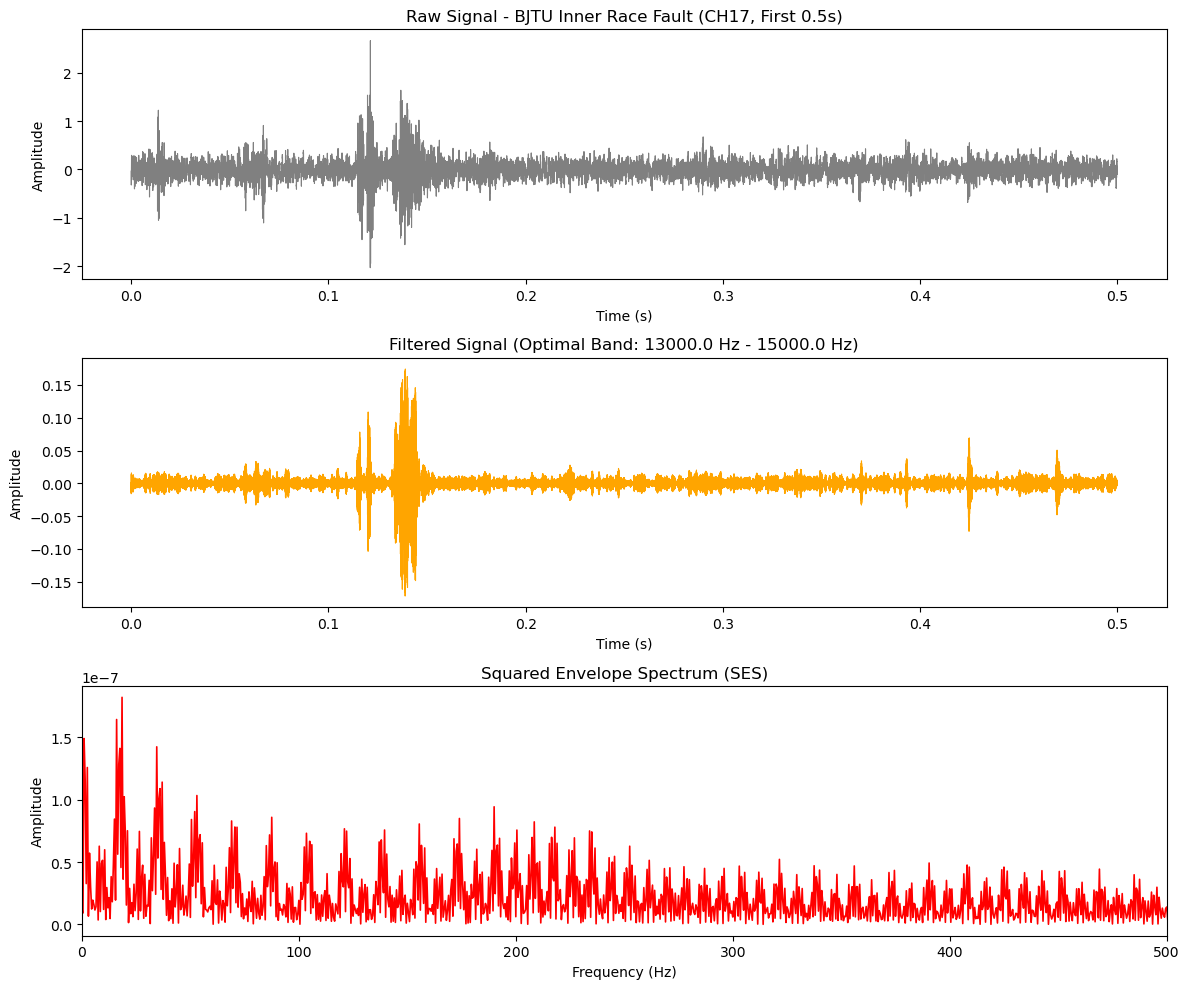

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft, butter, filtfilt, hilbert, welch
from scipy.stats import kurtosis

def compute_kurtogram_stft(x, fs, n_levels=6):
    """
    基于 STFT 的简易谱峭图计算，寻找最优中心频率和带宽
    (已加入真实工业数据的频段边界保护)
    """
    N = len(x)
    kurtogram = []
    freq_axes = []
    window_lengths = [2**(i+4) for i in range(n_levels)] 
    
    max_kurt = -1
    opt_fc = 0
    opt_bw = 0
    
    for nperseg in window_lengths:
        f, t, Zxx = stft(x, fs=fs, window='hann', nperseg=nperseg, noverlap=nperseg*3//4)
        kurt_values = kurtosis(np.abs(Zxx), axis=1, fisher=False) 
        
        # 【核心修复区】：边界约束
        # 强制要求中心频率远离 0Hz 和 Nyquist 频率，预留出至少 1500Hz 的安全裕度
        valid_indices = np.where((f > 500) & (f < (fs / 2 - 1500)))[0]
        
        if len(valid_indices) == 0:
            continue
            
        f_valid = f[valid_indices]
        kurt_valid = kurt_values[valid_indices]
        
        # 在安全频段内寻找最大峭度
        current_max_idx = np.argmax(kurt_valid)
        if kurt_valid[current_max_idx] > max_kurt:
            max_kurt = kurt_valid[current_max_idx]
            opt_fc = f_valid[current_max_idx]
            opt_bw = fs / nperseg

    return opt_fc, opt_bw, max_kurt, kurtogram, window_lengths

def extract_envelope_spectrum(x, fs, fc, bw):
    """
    利用给定的中心频率和带宽进行带通滤波，并提取平方包络谱
    """
    nyq = 0.5 * fs
    low = max(0.1, (fc - bw/2)) / nyq  
    high = min(nyq - 0.1, (fc + bw/2)) / nyq 
    
    if low >= high:
         raise ValueError("滤波器参数错误，请检查输入信号或参数")
         
    b, a = butter(4, [low, high], btype='band')
    x_filtered = filtfilt(b, a, x)
    analytic_signal = hilbert(x_filtered)
    squared_envelope = np.abs(analytic_signal)**2
    
    squared_envelope -= np.mean(squared_envelope)
    # 对于 64kHz 的数据，welch 方法的分段长度可以适当设长一些以提高频率分辨率
    f_env, Pxx_env = welch(squared_envelope, fs, nperseg=min(len(x), int(fs*4)))
    
    return x_filtered, squared_envelope, f_env, Pxx_env

# ==========================================
# 真实数据集处理流水线
# ==========================================
if __name__ == "__main__":
    # 1. 设置采样率
    fs = 64000
    
    # 2. 读取 BJTU 真实数据
    print("正在读取 BJTU 数据集...")
    file_path = '../数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv'
    df = pd.read_csv(file_path, usecols=['CH17'])
    
    # 【关键修复】：将 DataFrame 转换为 1D Numpy Array
    # 为了保证计算速度，截取前 2 秒数据 (128,000 个数据点) 进行处理
    raw_signal_full = df['CH17'].values
    process_length = fs * 2 
    raw_signal = raw_signal_full[:process_length]

    # 3. 运行谱峭图寻优
    print("开始计算谱峭图...")
    opt_fc, opt_bw, max_kurt, _, _ = compute_kurtogram_stft(raw_signal, fs, n_levels=8)
    print(f"全局最优参数定位完成：")
    print(f"最优中心频率 (fc) = {opt_fc:.2f} Hz")
    print(f"最优带宽 (Bw) = {opt_bw:.2f} Hz")
    print(f"最大峭度值 = {max_kurt:.2f}")

    # 4. 根据最优参数提取平方包络谱
    print("正在提取平方包络谱...")
    x_filtered, squared_envelope, f_env, Pxx_env = extract_envelope_spectrum(raw_signal, fs, opt_fc, opt_bw)

    # 5. 结果可视化 (绘制三层图进行对比)
    plt.figure(figsize=(12, 10))
    
    # 子图1：原始信号 (为了看清波形，时域只展示 0.5 秒)
    t_plot = np.arange(int(fs * 0.5)) / fs
    plt.subplot(3, 1, 1)
    plt.plot(t_plot, raw_signal[:int(fs * 0.5)], color='gray', linewidth=0.8)
    plt.title("Raw Signal - BJTU Inner Race Fault (CH17, First 0.5s)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    # 子图2：最佳频带滤波后的信号
    plt.subplot(3, 1, 2)
    plt.plot(t_plot, x_filtered[:int(fs * 0.5)], color='orange', linewidth=0.8)
    plt.title(f"Filtered Signal (Optimal Band: {opt_fc-opt_bw/2:.1f} Hz - {opt_fc+opt_bw/2:.1f} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    
    # 子图3：平方包络谱 (SES)
    plt.subplot(3, 1, 3)
    plt.plot(f_env, Pxx_env, color='red', linewidth=1.2)
    plt.title("Squared Envelope Spectrum (SES)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    # 重点观察 0~500Hz 的低频区段，这里包含轴承故障特征
    plt.xlim(0, 500) 
    
    plt.tight_layout()
    plt.show()

In [ ]:
    file_path = '数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv'
    df = pd.read_csv(file_path, usecols=['CH17'])
    
    # 【关键修复】：将 DataFrame 转换为 1D Numpy Array
    # 为了保证计算速度，截取前 2 秒数据 (128,000 个数据点) 进行处理
    raw_signal_full = df['CH17'].values

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from scipy.linalg import toeplitz

正在处理数据...
处理完成！谱峭度锁定的最优中心频率为: 25500.00 Hz


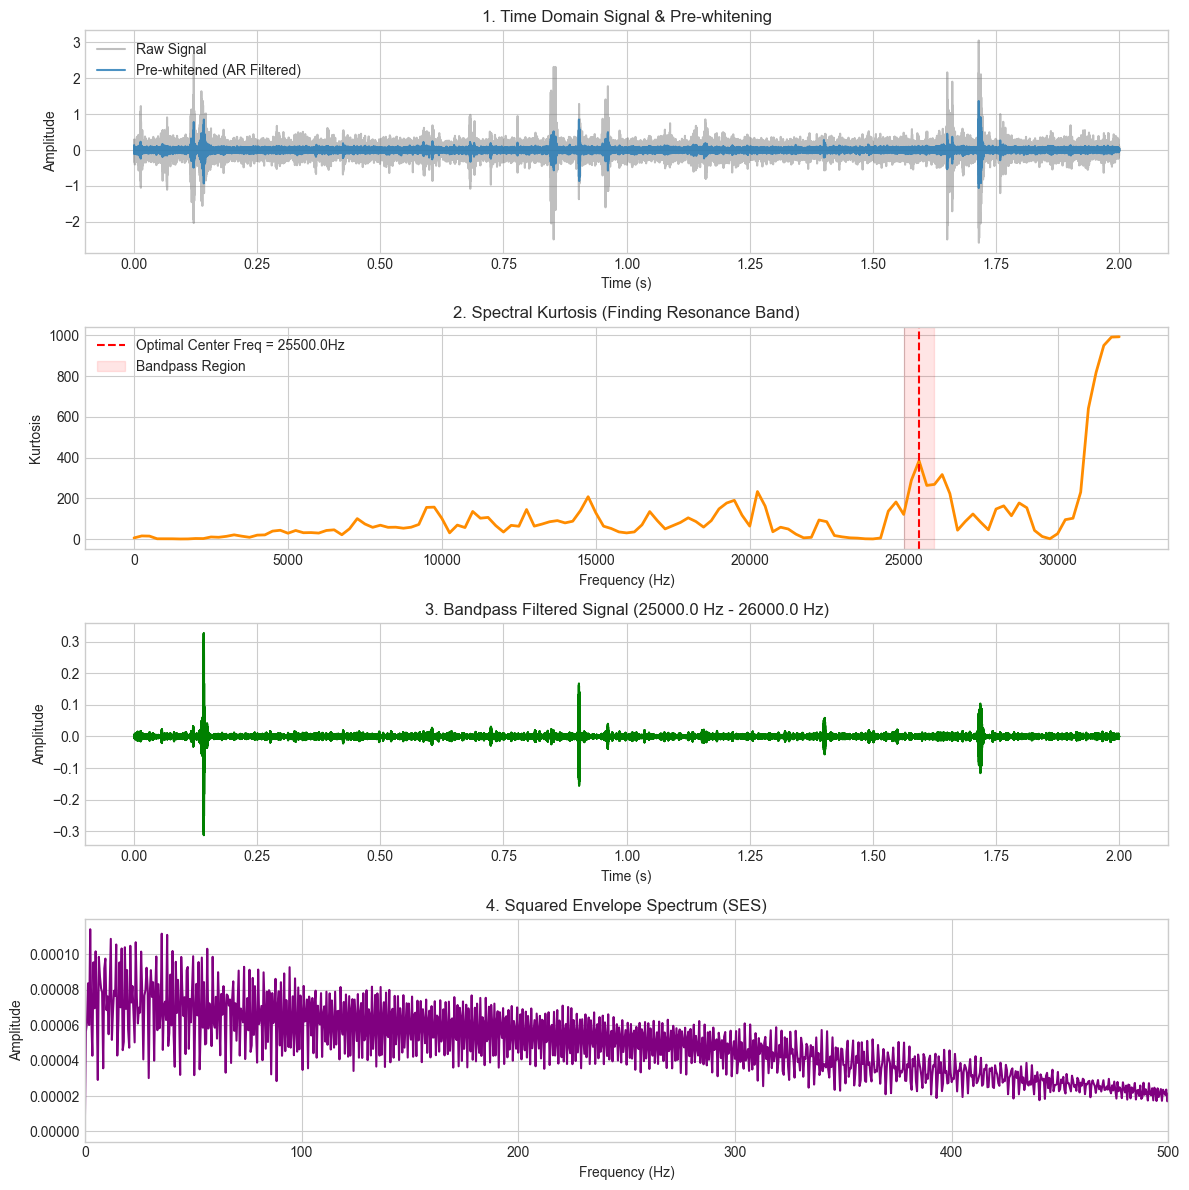

In [22]:
# ==========================================
# 核心算法：论文标准流水线封装
# ==========================================
def ar_prewhiten(y, order=10):
    """
    Step 1: 预白化 (AR滤波器)
    利用自回归模型滤除齿轮/转轴等确定性（周期性）干扰信号，提取包含冲击的残差。
    """
    # 计算自相关序列并构建 Toeplitz 矩阵求解 AR 系数
    r = np.correlate(y, y, mode='full')[len(y)-1 : len(y)+order]
    a = np.linalg.solve(toeplitz(r[:-1]), -r[1:])
    ar_coeffs = np.concatenate(([1], a))
    
    # 滤波输出残差
    residual = signal.lfilter(ar_coeffs, [1], y)
    return residual

def bearing_diagnostics_pipeline(raw_data, fs, ar_order=20, nperseg=256, bandwidth=1000):
    """
    更新版：增加了边缘保护，防止极高频噪声导致滤波器崩溃
    """
    # 1. 预白化
    whitened_sig = ar_prewhiten(raw_data, order=ar_order)
    
    # 2. 谱峭度寻找最优频带
    f_stft, t_stft, Zxx = signal.stft(whitened_sig, fs, nperseg=nperseg)
    sk = stats.kurtosis(np.abs(Zxx), axis=1)
    
    # 【核心修复区 1】：砍掉最后 10% 的极高频区，防止算法被奈奎斯特边缘的假阳性噪声吸引
    valid_limit = int(len(f_stft) * 0.9) 
    optimal_idx = np.argmax(sk[:valid_limit]) # 只在安全范围内找最大值
    fc = f_stft[optimal_idx] 
    
    # 3. 带通滤波
    # 【核心修复区 2】：给滤波器截止频率留出更大的安全裕度 (从 0.1 扩大到 100)
    f_low = max(100, fc - bandwidth / 2)
    f_high = min(fs / 2 - 100, fc + bandwidth / 2)
    
    b, a = signal.butter(4, [f_low, f_high], btype='bandpass', fs=fs)
    filtered_sig = signal.filtfilt(b, a, whitened_sig)
    
    # 4. 平方包络谱 (SES)
    analytic_sig = signal.hilbert(filtered_sig)
    sq_envelope = np.abs(analytic_sig) ** 2
    
    # 去直流
    sq_envelope -= np.mean(sq_envelope)
    
    # 滤除可能的异常值(NaN)防止画图崩溃
    sq_envelope = np.nan_to_num(sq_envelope)
    
    n = len(sq_envelope)
    freqs = np.fft.rfftfreq(n, 1/fs)
    ses_amp = np.abs(np.fft.rfft(sq_envelope)) / n
    
    return whitened_sig, f_stft, sk, fc, filtered_sig, freqs, ses_amp, f_low, f_high

# ==========================================
# 用户数据执行与可视化区
# ==========================================
if __name__ == '__main__':
    # ---------------------------------------------------------
    # TODO: 在此处加载您的真实数据
    # ---------------------------------------------------------
    fs = 64000  # 请修改为您设备的真实采样率 (例如 12000 或 25600)
    
    # --- 为保证脚本直接运行不报错，这里临时生成一段纯随机白噪声充当占位符 ---
    # !!! 运行您自己的数据时，请务必删除下面这行占位代码 !!!
    file_path = '数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv'
    df = pd.read_csv(file_path, usecols=['CH17'])
    
    # 【关键修复】：将 DataFrame 转换为 1D Numpy Array
    # 为了保证计算速度，截取前 2 秒数据 (128,000 个数据点) 进行处理
    real_data = df['CH17'].values
    # ---------------------------------------------------------

    # 截取一段数据进行分析 (例如取前 2 秒的数据，数据太长会影响画图和运算速度)
    analyze_length = min(len(real_data), int(fs * 2))
    data_to_analyze = real_data[:analyze_length]
    t = np.arange(analyze_length) / fs

    # 运行诊断流水线
    print("正在处理数据...")
    whitened, f_sk, sk, fc, filtered, freqs_ses, ses_amp, f_low, f_high = bearing_diagnostics_pipeline(
        data_to_analyze, 
        fs=fs, 
        ar_order=20,       # AR模型阶数，通常10-30之间
        bandwidth=1000     # 带通滤波带宽，可根据采样率和共振区宽度微调
    )
    print(f"处理完成！谱峭度锁定的最优中心频率为: {fc:.2f} Hz")

    # 绘制结果图
    plt.figure(figsize=(12, 12))

    # 图1: 原始信号与预白化结果
    plt.subplot(4, 1, 1)
    plt.plot(t, data_to_analyze, label='Raw Signal', alpha=0.5, color='gray')
    plt.plot(t, whitened, label='Pre-whitened (AR Filtered)', alpha=0.8, color='#1f77b4')
    plt.title('1. Time Domain Signal & Pre-whitening')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()

    # 图2: 谱峭度图
    plt.subplot(4, 1, 2)
    plt.plot(f_sk, sk, color='darkorange', linewidth=2)
    plt.axvline(x=fc, color='red', linestyle='--', label=f'Optimal Center Freq = {fc:.1f}Hz')
    plt.axvspan(f_low, f_high, color='red', alpha=0.1, label='Bandpass Region')
    plt.title('2. Spectral Kurtosis (Finding Resonance Band)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Kurtosis')
    plt.legend()

    # 图3: 带通滤波后的冲击信号
    plt.subplot(4, 1, 3)
    plt.plot(t, filtered, color='green')
    plt.title(f'3. Bandpass Filtered Signal ({f_low:.1f} Hz - {f_high:.1f} Hz)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    # 图4: 平方包络谱 (SES) - 故障特征提取
    
    plt.subplot(4, 1, 4)
    plt.plot(freqs_ses, ses_amp, color='purple')
    plt.xlim(0, 500) # 通常看 0-500Hz 的低频区找故障频率
    plt.title('4. Squared Envelope Spectrum (SES)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')

    plt.tight_layout()
    plt.show()